# Stage 9 — VaR & Fidelity Check

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `08_classical_postprocessing.ipynb`
**Next:** — (final stage) — see `results/FINAL_REPORT.md`

---

The last box of the architecture diagram. The quantum-derived loss CDF from Stage 8 is turned into the risk figure a bank reports — the **95% Value at Risk** — and the whole distribution is checked against the classical baseline with the **Hellinger fidelity**. The result decides between the two exits of the diagram: **ACCEPT** (distribution validated) or **RE-CALIBRATE** (re-run Stage 6B automatically). Finally, the loop is stress-tested with a simulated drift event.

## 1. What Is Being Checked? (General Overview)

**Value at Risk** at confidence $c$ is the smallest loss $L$ such that the probability of losing *at most* $L$ is at least $c$:

$$
\mathrm{VaR}_c = \min\{\,L : P(\text{Loss} \le L) \ge c\,\}.
$$

It is the quantity regulators (Basel) ask for and the reason the whole GCI/QAE machinery exists. **Hellinger fidelity** measures how close two whole distributions are, $F_H(p,q) = \big(\sum_i \sqrt{p_i q_i}\big)^2 \in [0,1]$. The base paper uses exactly this pair: the VaR, and $F_H$ between the hardware distribution and the simulated one (98.9 %, Sec. IV-C).

The paper makes an important remark: *"The main result is therefore not the recovery of the 95 % VaR itself, since the VaR is classically determined from the reference distribution, but rather the fact that the quantum algorithm produces the same distribution from which the VaR is obtained."* With a single asset the loss is either \$0 or \$1000 and $P(L=0)\approx 0.75 < 0.95$, so **any** distribution with a default probability above 5 % gives VaR = \$1000. The VaR check is necessary but weak; the fidelity check is the real test.

## 2. Why We Do This

1. **It is the acceptance test of the pipeline** — the decision node of the architecture diagram (ACCEPT / RE-CALIBRATE).
2. **It makes the automated calibration a closed loop.** In the base paper, a failing distribution means a person goes back to the lab and sweeps angles again. Here a failed check triggers Stage 6B as a function call — the practical meaning of "replacing the manual grid sweep".
3. **It separates the error sources.** Comparing against the *noiseless quantum* reference isolates hardware error; comparing against the *classical GCI* distribution adds the modelling errors of Stages 2 and 4 (linearisation of PD(z), ansatz expressivity).

## 3. Where This Fits in the Project Pipeline

This is **Stage 9 of 9**.

- **Input:** `stage06_retuning.json` (calibrated angles), `stage07_execution.json` (measured distributions), `stage08_postprocessing.json` (loss PDFs/CDFs and classical references).
- **Output:** `results/stage09_final_report.json` (all metrics, decisions and recalibration logs) and `results/FINAL_REPORT.md` (the one-page summary of the project).

Four fidelities are reported per variant:

| Metric | Compares | What a shortfall means |
|---|---|---|
| $F_H$ vs ideal | full $(n{+}1)$-bit distribution vs noiseless circuit | hardware error left after correction (**the paper's metric; used for ACCEPT**) |
| $F_H$ vs classical joint | full distribution vs classical $P(z_b)\,\mathrm{PD}(z_b)$ | hardware error + modelling error (Stage 2 linearisation, Stage 4 ansatz) |
| $F_H$ loss distribution | $\{P(L{=}0), P(L{=}1000)\}$ vs classical | error in the default probability / expected loss |
| $F_H$ z-marginal | latent-factor marginal vs target Gaussian | how well the Gaussian loader survives |

## 4. Implementation

### 4.1 VaR extraction and the fidelity table

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.stages import fidelity_table, acceptance_check, recalibration_loop, config_snapshot
from src.noise_model import ControlDrift
from src.pipeline_io import load_stage_output, save_json, save_fig
from src.report import write_final_report

BLUE, RED, GREEN, GREY, ORANGE, PURPLE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22", "#8e44ad"
COLORS = {"ideal_noiseless": BLUE, "noisy_uncalibrated": RED, "uncalibrated_REM": "#f1948a",
          "6A_grid_REM": ORANGE, "6B_auto_REM": GREEN, "6B_auto_REM_ZNE": PURPLE}

s6 = load_stage_output("stage06_retuning.json")
s7 = load_stage_output("stage07_execution.json")
s8 = load_stage_output("stage08_postprocessing.json")

tables = {}
for n in C.REGISTER_SIZES:
    key = f"{n}_qubit"
    tables[n] = fidelity_table(n, s7[key], s8[key])
    cl = s8[key]["classical"]
    print(f"=== {n}-qubit register ===   classical VaR95: discrete grid = ${cl['classical_discrete_grid']['var']:.0f}, "
          f"Monte Carlo = ${cl['classical_monte_carlo_continuous']['var']:.0f}")
    print(f"{'variant':18s} | {'F vs ideal':>15} | {'F vs classical':>14} | {'F loss':>6} | {'F z':>6} | "
          f"{'VaR95':>5} | {'VaR ok in all reps':>18}")
    for k, r in tables[n].items():
        print(f"{k:18s} | {r['F_vs_ideal_mean']:.4f} +/- {r['F_vs_ideal_std']:.4f} | "
              f"{r['F_vs_classical_joint_mean']:14.4f} | {r['F_loss_distribution_vs_classical']:6.4f} | "
              f"{r['F_z_marginal_vs_target_gaussian']:6.4f} | {r['VaR95']:5.0f} | {str(r['VaR95_all_repeats_match']):>18}")
    print()

=== 2-qubit register ===   classical VaR95: discrete grid = $1000, Monte Carlo = $1000
variant            |      F vs ideal | F vs classical | F loss |    F z | VaR95 | VaR ok in all reps
ideal_noiseless    | 1.0000 +/- 0.0000 |         1.0000 | 1.0000 | 1.0000 |  1000 |               True
noisy_uncalibrated | 0.8794 +/- 0.0026 |         0.8802 | 0.9913 | 0.8940 |  1000 |               True
uncalibrated_REM   | 0.9218 +/- 0.0027 |         0.9226 | 0.9889 | 0.9396 |  1000 |               True
6A_grid_REM        | 0.9391 +/- 0.0022 |         0.9394 | 1.0000 | 0.9437 |  1000 |               True
6B_auto_REM        | 0.9819 +/- 0.0016 |         0.9820 | 0.9993 | 0.9837 |  1000 |               True
6B_auto_REM_ZNE    | 0.9983 +/- 0.0007 |         0.9983 | 0.9999 | 0.9994 |  1000 |               True

=== 3-qubit register ===   classical VaR95: discrete grid = $1000, Monte Carlo = $1000
variant            |      F vs ideal | F vs classical | F loss |    F z | VaR95 | VaR ok in all reps
ideal

Every variant — even the uncalibrated one — reports VaR = \$1000 in every single repetition, exactly as predicted in §1: the VaR check alone cannot tell a good circuit from a bad one here. The fidelity columns can.

Note also the ceiling in the "vs classical" and "z" columns for the 3-qubit register: even the *noiseless* circuit only reaches the fidelity allowed by the 3-parameter star ansatz found in Stage 4. That part is a modelling limit, not a hardware one, and no amount of calibration can remove it.

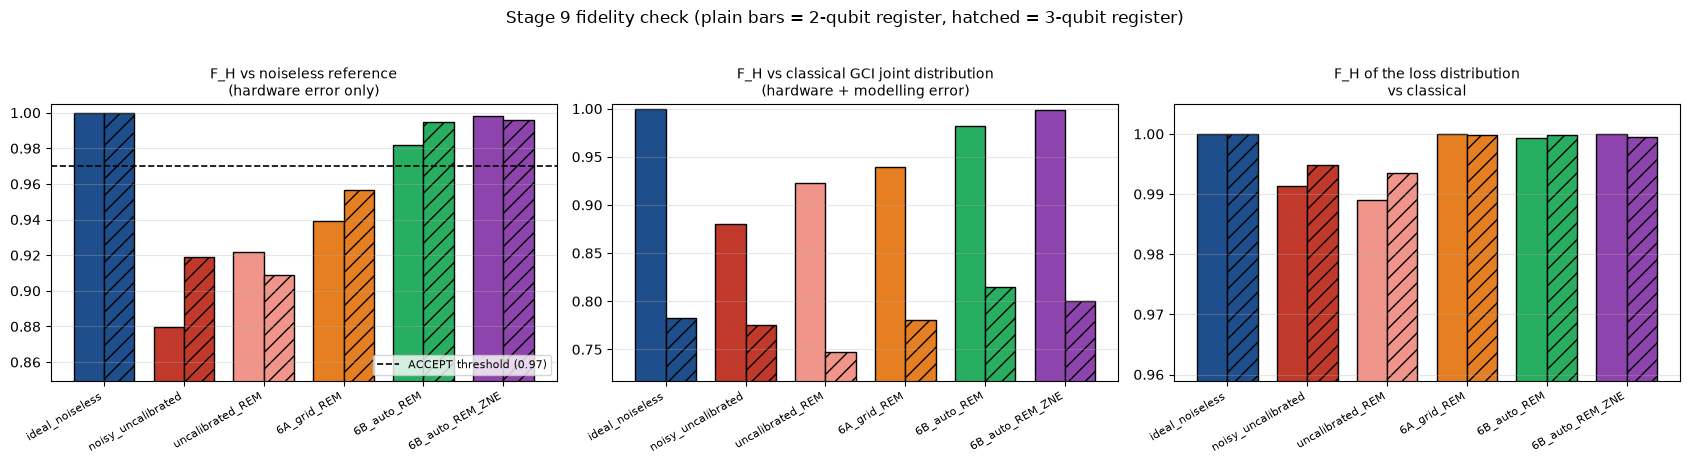

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
keys = list(tables[2])
metrics = [("F_vs_ideal_mean", "F_H vs noiseless reference\n(hardware error only)"),
           ("F_vs_classical_joint_mean", "F_H vs classical GCI joint distribution\n(hardware + modelling error)"),
           ("F_loss_distribution_vs_classical", "F_H of the loss distribution\nvs classical")]
for ax, (m, title) in zip(axes, metrics):
    x = np.arange(len(keys)); w = 0.38
    for j, n in enumerate(C.REGISTER_SIZES):
        vals = [tables[n][k][m] for k in keys]
        ax.bar(x + (j - 0.5) * w, vals, w, color=[COLORS[k] for k in keys], edgecolor="k",
               hatch="" if n == 2 else "//")
    if m == "F_vs_ideal_mean":
        ax.axhline(C.FIDELITY_THRESHOLD, color="k", ls="--", lw=1.2, label=f"ACCEPT threshold ({C.FIDELITY_THRESHOLD})")
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xticks(x); ax.set_xticklabels(keys, rotation=30, ha="right", fontsize=8)
    lo = min(tables[n][k][m] for n in C.REGISTER_SIZES for k in keys)
    ax.set_ylim(max(0.0, lo - 0.03), 1.005); ax.set_title(title, fontsize=10); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Stage 9 fidelity check (plain bars = 2-qubit register, hatched = 3-qubit register)", y=1.02)
plt.tight_layout(); save_fig(fig, "stage09_fidelity_summary.png"); plt.show()

### 4.2 The decision: ACCEPT or RE-CALIBRATE

The deployed pipeline is **6B angles + readout mitigation** — cheap to run (one circuit per estimate), unlike ZNE which multiplies the gate count by up to 5. It is accepted if its Hellinger fidelity against the noiseless reference, averaged over the 20 repetitions of Stage 7, reaches the threshold set in `src/config.py`.

In [3]:
decisions = {}
for n in C.REGISTER_SIZES:
    f = tables[n]["6B_auto_REM"]["F_vs_ideal_mean"]
    decisions[n] = acceptance_check(f)
    print(f"{n}-qubit register: F_H(6B + REM) = {f:.4f}  vs threshold {C.FIDELITY_THRESHOLD}  ->  {decisions[n]}")

2-qubit register: F_H(6B + REM) = 0.9819  vs threshold 0.97  ->  ACCEPT
3-qubit register: F_H(6B + REM) = 0.9946  vs threshold 0.97  ->  ACCEPT


### 4.3 The closed loop under a drift event

Real chips do not stay calibrated. We emulate a **drift event** — the device is re-calibrated overnight and every physical qubit gets a *new* amplitude/offset miscalibration (`DRIFT_EPS_DAY2`, `DRIFT_DELTA_DEG_DAY2` in `src/config.py`). The yesterday-optimal 6B angles are sent to the "new" chip, the fidelity check runs, and whenever it fails the RE-CALIBRATE branch re-runs Stage 6B automatically (warm-started from the current angles) until the check passes — exactly the feedback arrow from box 9 back to box 6B in the architecture diagram.

For comparison: the manual 6A procedure would have to repeat its full sweep on the new chip.

In [4]:
loops = {}
for n in C.REGISTER_SIZES:
    x6b = s6[f"{n}_qubit"]["calibrated_parameters"]["auto_6B"]
    print(f"=== {n}-qubit register — today's chip (the one Stage 6 calibrated on) ===")
    day1 = recalibration_loop(n, x6b, ControlDrift())
    print(f"=== {n}-qubit register — after the drift event ===")
    day2 = recalibration_loop(n, x6b, ControlDrift(C.DRIFT_EPS_DAY2, C.DRIFT_DELTA_DEG_DAY2))
    grid_cost = s6[f"{n}_qubit"]["gci"]["methods"]["grid_6A"]["n_evals"]
    print(f"   automatic re-calibration cost: {day2['total_recalibration_evals']} circuit runs "
          f"(a manual 6A re-sweep would cost {grid_cost})\n")
    loops[n] = (day1, day2)

=== 2-qubit register — today's chip (the one Stage 6 calibrated on) ===


  round 0: F_H = 0.9818  ->  ACCEPT
=== 2-qubit register — after the drift event ===


  round 0: F_H = 0.5283  ->  RE-CALIBRATE


     re-ran Stage 6B automatically (204 circuit evaluations)
  round 1: F_H = 0.9715  ->  ACCEPT
   automatic re-calibration cost: 204 circuit runs (a manual 6A re-sweep would cost 347)

=== 3-qubit register — today's chip (the one Stage 6 calibrated on) ===


  round 0: F_H = 0.9943  ->  ACCEPT
=== 3-qubit register — after the drift event ===


  round 0: F_H = 0.6761  ->  RE-CALIBRATE


     re-ran Stage 6B automatically (204 circuit evaluations)
  round 1: F_H = 0.9917  ->  ACCEPT
   automatic re-calibration cost: 204 circuit runs (a manual 6A re-sweep would cost 477)



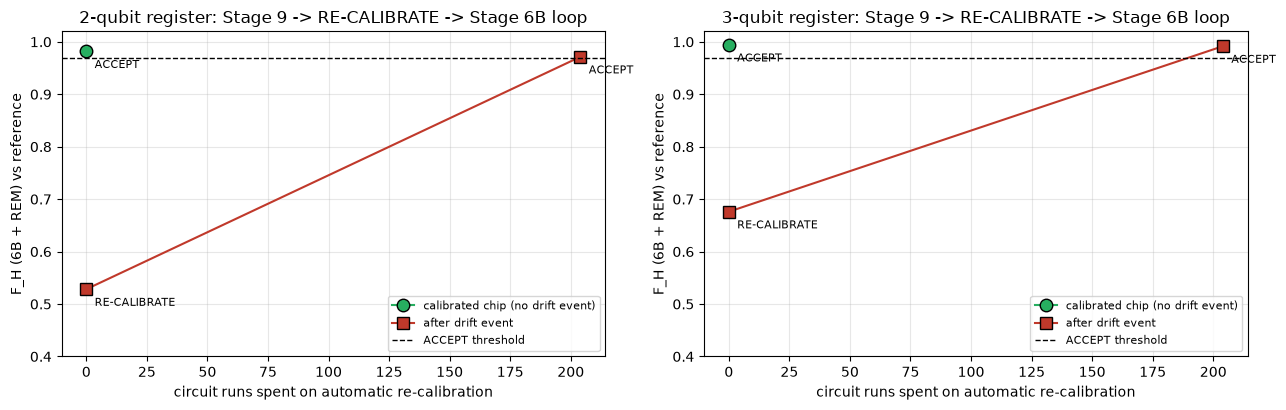

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, n in zip(axes, C.REGISTER_SIZES):
    for (loop, lab, col, mk) in [(loops[n][0], "calibrated chip (no drift event)", GREEN, "o"),
                                 (loops[n][1], "after drift event", RED, "s")]:
        r = loop["rounds"]
        xs = [x["cumulative_calibration_evals"] for x in r]
        ys = [x["fidelity"] for x in r]
        ax.plot(xs, ys, "-" + mk, color=col, ms=9, mec="k", label=lab)
        for x, y, d in zip(xs, ys, [x["decision"] for x in r]):
            ax.annotate(d, (x, y), textcoords="offset points", xytext=(6, -12), fontsize=8)
    ax.axhline(C.FIDELITY_THRESHOLD, color="k", ls="--", lw=1, label="ACCEPT threshold")
    ax.set_xlabel("circuit runs spent on automatic re-calibration"); ax.set_ylabel("F_H (6B + REM) vs reference")
    ax.set_title(f"{n}-qubit register: Stage 9 -> RE-CALIBRATE -> Stage 6B loop")
    ax.set_ylim(0.4, 1.02); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); save_fig(fig, "stage09_recalibration_loop.png"); plt.show()

### 4.4 Saving the final results and the one-page report

In [6]:
out = {"config": config_snapshot(), "threshold": C.FIDELITY_THRESHOLD}
for n in C.REGISTER_SIZES:
    key = f"{n}_qubit"
    out[key] = {"fidelity_table": tables[n], "deployed_pipeline": "6B_auto_REM",
                "deployed_fidelity": tables[n]["6B_auto_REM"]["F_vs_ideal_mean"], "decision": decisions[n],
                "loop_day1": loops[n][0], "loop_day2_drift_event": loops[n][1],
                "classical_var95": s8[key]["classical"]["classical_discrete_grid"]["var"],
                "classical_mc_var95": s8[key]["classical"]["classical_monte_carlo_continuous"]["var"]}
path = save_json(out, "stage09_final_report.json")
rpath = write_final_report(s6, s7, s8, out)
print(f"Saved -> {path}\nSaved -> {rpath}\n")
print(open(rpath).read())

Saved -> /home/muthuraam/quantum-credit-risk-vqc/results/stage09_final_report.json
Saved -> /home/muthuraam/quantum-credit-risk-vqc/results/FINAL_REPORT.md

# Final Report — Quantum Circuit-Based Adaptation for Credit Risk Analysis

Replication (on a noise-emulated Qiskit simulator) of Ahmad et al., *IEEE Trans. Quantum Eng.* 7, 3103316 (2026), with an automated calibration loop replacing the paper's manual grid sweep.

Model: one asset, one latent factor, p0 = 0.25, rho = 0.027, LGD = $1000. Registers studied: 2-qubit, 3-qubit latent-factor register (+1 asset qubit).

## Stage 6 — calibration cost vs. quality (full GCI circuit)

| register | method | circuit runs | F_H vs noiseless reference |
|---|---|---|---|
| 2q | uncalibrated (Stage 4 angles) | 0 | 0.9225 |
| 2q | 6A grid sweep (base paper) | 347 | 0.9389 |
| 2q | **6B automated (this project)** | 204 | 0.9818 |
| 2q | ablation: joint SPSA | 308 | 0.9820 |
| 2q | ablation: joint BO | 70 | 0.9727 |
| 3q | uncalibrated (Stage 4 ang

## 5. Conclusions

1. **Replication.** The full base-paper pipeline — Vasicek/GCI model, $\sin^2$ encoding, $R_y$+CNOT Gaussian loader trained with parameter-shift + Adam, SABRE transpilation to a native `rz/sx/x/cz` gate set, in-situ angle retuning by grid sweep, bitstring post-processing, CDF, VaR and Hellinger fidelity — runs end to end, for both a 2-qubit and a 3-qubit latent-factor register. The headline numbers agree with the paper: $P(L\le 0)\approx 0.75$, $P(L\le 1000)=1$, VaR$_{95}$ = \$1000, and a paper-style grid sweep that moves the 2-qubit loader angle to ≈234° (paper: 224°–237°).
2. **Novelty — automated calibration.** Replacing the manual grid sweep by a hierarchical BO → BO → SPSA loop reaches a higher Hellinger fidelity with fewer than half the circuit executions, for both register sizes (Stage 6). The ablations show why the design is hierarchical: a single optimiser on all angles at once is less reliable.
3. **Novelty — mitigation benchmark.** Retuning, readout mitigation and ZNE fix *different* errors. Readout mitigation alone does not rescue an uncalibrated circuit; retuning + readout mitigation reaches about 98–99.5 % fidelity; ZNE adds a little more fidelity at a large gate-count cost and does not reliably improve the loss statistics.
4. **Novelty — closed loop.** After a simulated drift event the check fails, Stage 6B re-runs itself, and the pipeline is accepted again — no human in the loop.

## 6. Limitations (stated honestly)

- **Simulator, not hardware.** The device is a Qiskit Aer simulator with an emulated noise model (depolarizing, readout, coherent drift). Real chips have further effects (crosstalk, leakage, non-Markovian noise, time-varying drift) that are not modelled.
- **The drift is emulated at the level of commanded angles**, using the initial SABRE layout; rotations applied after routing SWAPs are approximated.
- **Toy portfolio.** One asset, one risk factor, LGD = \$1000 — the VaR is trivially \$1000, as the paper also notes. The fidelity numbers carry the real information.
- **3-qubit loader expressivity.** The star ansatz with three $R_y$ angles cannot represent the 8-bin Gaussian exactly (noiseless $F_H \approx 0.78$ vs the ideal Gaussian); this is inherited from Stage 4 and limits the fidelity against the classical model.

## 7. Future Work

- **Real IBM Quantum hardware** (free tier) — the calibration loop only needs measured counts, so it can run unchanged against a real backend.
- **Task-aware calibration objective** — add the loss-distribution distance to the Hellinger objective so the default probability is weighted as much as a bank would weight it.
- **Scaling to 2 assets / 2 risk factors (6 qubits)** — the paper only projects this case; the code is written for general register sizes and default patterns.
- **Richer ansatz for the 3-qubit loader** (a second rotation layer) to lift the expressivity ceiling.
- **Full QAE** on top of the calibrated uncertainty model, to estimate VaR by amplitude estimation rather than direct sampling.

---
*End of the pipeline. Summary: `results/FINAL_REPORT.md` · Master runner: `main.ipynb` / `python run_pipeline.py`*